<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafio, Traductor**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase (https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/blob/may_2026/Clase%206/C%C3%B3digo/Traductor.ipynb) y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

Importamos las librerías necesarias

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

Descargamos el dataset de traducción español-inglés

In [ ]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Pares disponibles en el archivo: {len(lines)}")

Pares disponibles en el archivo: 118964


**Extensión 1: más datos.** En la versión de clase se usaban 10.000 oraciones. Acá subimos a 30.000 para que el modelo vea más vocabulario y más variedad de frases.

In [ ]:
MAX_NUM_SENTENCES = 30000

np.random.seed(40)
np.random.shuffle(lines)

Cargamos los datos y agregamos los tokens de inicio y fin a la secuencia de salida

In [ ]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Oraciones cargadas: {len(input_sentences)}")

Oraciones cargadas: 30000


In [ ]:
print(input_sentences[0])
print(output_sentences[0])
print(output_sentences_inputs[0])

Somebody stole my car.
Alguien robó mi auto. <eos>
<sos> Alguien robó mi auto.


Se aplica tokenización. Sw sube el vocabulario a 12000 palabras

In [ ]:
MAX_VOCAB_SIZE = 12000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<unk>')
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

# El tamaño de cada embedding
max_idx_in  = max(max(s) for s in input_integer_seq if s)
max_idx_out = max(max(s) for s in output_integer_seq + output_input_integer_seq if s)
nb_words         = max_idx_in + 1
num_words_output = max_idx_out + 1

print(f"Vocabulario EN: {len(word2idx_inputs)} (embedding={nb_words})")
print(f"Vocabulario ES: {len(word2idx_outputs)} (embedding={num_words_output})")

Vocabulario EN: 8073 (embedding=8074)
Vocabulario ES: 13954 (embedding=12000)


**Extensión 2: secuencias más largas.** En clase se usaba `max_input_len=20` / `max_out_len=22`.

In [ ]:
len_inputs  = [len(s) for s in input_integer_seq]
len_outputs = [len(s) for s in output_integer_seq]

print(f"Largo máximo entrada: {max(len_inputs)}  | percentil 95: {int(np.percentile(len_inputs, 95))}")
print(f"Largo máximo salida:  {max(len_outputs)} | percentil 95: {int(np.percentile(len_outputs, 95))}")

# Tomamos un máximo
max_input_len = 30
max_out_len   = 32
print(f"\nmax_input_len={max_input_len}  max_out_len={max_out_len}")

Largo máximo entrada: 34  | percentil 95: 11
Largo máximo salida:  43 | percentil 95: 12

max_input_len=30  max_out_len=32


Aplicaar padding a las secuencias

In [ ]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

print("encoder_input :", encoder_input_sequences.shape)
print("decoder_input :", decoder_input_sequences.shape)
print("decoder_output:", decoder_output_sequences.shape)

encoder_input : (30000, 30)
decoder_input : (30000, 32)
decoder_output: (30000, 32)


El target se pasa a one-hot dentro del pipeline (y no en memoria) porque con 30.000 oraciones y un vocabulario grande 

In [ ]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):

    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)          # shape (max_out_len, num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

Separamos en train y validación

In [ ]:
BATCH_SIZE = 64
val_split  = 0.15
split_idx  = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)

print(f"Train: {split_idx} oraciones | Val: {len(encoder_input_sequences) - split_idx} oraciones")

Train: 25500 oraciones | Val: 4500 oraciones


### Embeddings pre-entrenados (opcional)

Usamos GloVe para inicializar el embedding del **inglés** (la entrada del encoder). 

In [ ]:
# GloVe en pickle. Se descarga desde Google Drive con gdown,
_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

def _is_valid_pickle(path):
    """Chequea que el archivo no sea una página HTML de Drive."""
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
    except ImportError:
        os.system("pip install -q gdown")
        import gdown
    gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")

Descargando gloveembedding.pkl desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=1957e5cb-8af2-4a53-a0d5-b3889a0b6f4c
To: /content/gloveembedding.pkl
100%|██████████| 525M/525M [00:09<00:00, 55.9MB/s]

Descarga completada.


In [ ]:
def load_glove_embeddings(pkl_path):
    """Carga el pickle de GloVe y devuelve (word2idx, matrix_fn)."""
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

In [ ]:
def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

In [ ]:
def build_embedding_matrix(word2idx_inputs, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_inputs.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

In [ ]:
EMBED_DIM = 50

glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)
print(f"Palabras del inglés sin vector GloVe: {np.sum(np.sum(embedding_matrix**2, axis=1) == 0)}")

Palabras del inglés sin vector GloVe: 402


### **Modelo Seq2Seq**

**Extensión 3: cantidad de neuronas.** `n_units` es la cantidad de neuronas de las dos LSTM (encoder y decoder). 

In [ ]:
n_units = 256

El encoder lee la frase en inglés y devuelve sus estados finales `[h, c]`, que resumen la oración. 

In [ ]:
def build_encoder(nb_words, embed_dim, embedding_matrix, max_input_len, n_units):

    enc_inputs   = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)

    return enc_inputs, [state_h, state_c], enc_emb_layer, enc_lstm_layer

El decoder recibe los estados del encoder como estado inicial y con teacher forcing, aprende a generar la frase en español token a token.

In [ ]:
def build_decoder(num_words_output, max_out_len, n_units, encoder_states):

    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=encoder_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    return dec_inputs, dec_out, dec_emb_layer, dec_lstm_layer, dec_dense_layer

Construimos el modelo completo de entrenamiento

In [ ]:
enc_inputs, enc_states, enc_emb_layer, enc_lstm_layer = build_encoder(
    nb_words, EMBED_DIM, embedding_matrix, max_input_len, n_units
)
dec_inputs, dec_outputs, dec_emb_layer, dec_lstm_layer, dec_dense_layer = build_decoder(
    num_words_output, max_out_len, n_units, enc_states
)

model = Model([enc_inputs, dec_inputs], dec_outputs)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 32)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 30, 50)    │    403,700 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 32, 256)   │  3,072,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout     │ (None, 30, 50)    │          0 │ encoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 32, 256)   │          0 │ decoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 256),     │    314,368 │ encoder_dropout[… │
│                     │ (None, 256),      │            │                   │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 32, 256), │    525,312 │ decoder_dropout[… │
│                     │ (None, 256),      │            │ encoder_lstm[0][… │
│                     │ (None, 256)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 32, 12000) │  3,084,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,399,380 (28.23 MB)

 Trainable params: 6,995,680 (26.69 MB)

 Non-trainable params: 403,700 (1.54 MB)

Definimos los callbacks y compilamos

In [ ]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=4, restore_best_weights=True, verbose=1
)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    metrics=['accuracy']
)

Entrenamos

In [ ]:
hist = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/10
    399/Unknown 44s 92ms/step - accuracy: 0.7761 - loss: 2.9475

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


399/399 ━━━━━━━━━━━━━━━━━━━━ 51s 108ms/step - accuracy: 0.8007 - loss: 1.7771 - val_accuracy: 0.8230 - val_loss: 1.2283 - learning_rate: 5.0000e-04
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 80s 202ms/step - accuracy: 0.8177 - loss: 1.2688 - val_accuracy: 0.8264 - val_loss: 1.1681 - learning_rate: 5.0000e-04
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.8247 - loss: 1.1948 - val_accuracy: 0.8335 - val_loss: 1.0987 - learning_rate: 5.0000e-04
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 82s 107ms/step - accuracy: 0.8314 - loss: 1.1205 - val_accuracy: 0.8404 - val_loss: 1.0387 - learning_rate: 5.0000e-04
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 82s 206ms/step - accuracy: 0.8370 - loss: 1.0540 - val_accuracy: 0.8451 - val_loss: 0.9866 - learning_rate: 5.0000e-04
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 43s 108ms/step - accuracy: 0.8423 - loss: 0.9933 - val_accuracy: 0.8486 - val_loss: 0.9428 - learning_rate: 5.0000e-04
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - 

 accuracy

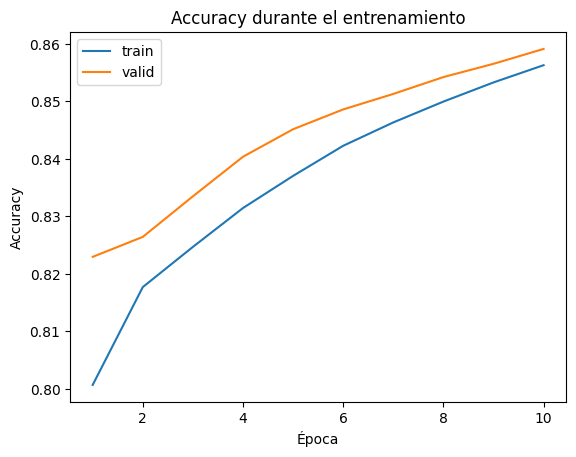

In [ ]:
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count, y=hist.history['accuracy'],     label='train')
sns.lineplot(x=epoch_count, y=hist.history['val_accuracy'], label='valid')
plt.title("Accuracy durante el entrenamiento")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.show()

### **Inferencia**

Para traducir armamos dos modelos que reutilizan las capas ya entrenadas: el encoder que entrega los estados, y el decoder que genera un token por vez realimentando su propia salida.

In [ ]:
def build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units):
    """Modelo de encoder que solo devuelve los estados."""
    enc_emb = enc_emb_layer(enc_inputs)                    
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    return Model(enc_inputs, [state_h, state_c])


def build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units):
    """Modelo de decoder paso a paso (un token por vez)."""
    dec_input_single = Input(shape=(1,), name='dec_input_single')
    dec_state_h_in   = Input(shape=(n_units,), name='dec_state_h')
    dec_state_c_in   = Input(shape=(n_units,), name='dec_state_c')

    dec_emb_single = dec_emb_layer(dec_input_single)      
    dec_out, h_out, c_out = dec_lstm_layer(
        dec_emb_single,
        initial_state=[dec_state_h_in, dec_state_c_in]
    )
    dec_out = dec_dense_layer(dec_out)

    return Model(
        [dec_input_single, dec_state_h_in, dec_state_c_in],
        [dec_out, h_out, c_out]
    )

In [ ]:
encoder_model = build_encoder_inference(enc_inputs, enc_emb_layer, enc_lstm_layer, n_units)
decoder_model = build_decoder_inference(dec_emb_layer, dec_lstm_layer, dec_dense_layer, n_units)

idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

Definimos la traducción. Dejamos un parámetro `sampling`: si es `False` elegimos siempre el token más probable (greedy); si es `True` muestreamos de la distribución usando una `temperature`

In [ ]:
def translate_sentence(input_seq, sampling=False, temperature=1.0):
    h, c = encoder_model.predict(input_seq, verbose=0)
    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict([target_seq, h, c], verbose=0)
        probs = output_tokens[0, 0, :]

        if sampling:
            # más temperatura = más variedad
            logits = np.log(probs + 1e-9) / temperature
            p = np.exp(logits) / np.sum(np.exp(logits))
            idx = np.random.choice(len(p), p=p)
        else:
            idx = np.argmax(probs)

        if idx == eos:
            break
        if idx > 0:
            output_sentence.append(idx2word_target[idx])
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)


def translate(text, sampling=False, temperature=1.0):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_sentence(seq, sampling=sampling, temperature=temperature)

### 5 ejemplos de traducciones generadas

 5 frases del dataset y comparamos la traducción real con la del modelo (greedy)

In [ ]:
np.random.seed(1)
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    pred = translate_sentence(seq)
    print(f"EN:        {input_sentences[i]}")
    print(f"ES (real): {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred): {pred}\n")

EN:        Stop bothering me.
ES (real): Dejate de joder.
ES (pred): no me gusta

EN:        They're yours.
ES (real): Son suyos.
ES (pred): no es tu verdad

EN:        Throw me the ball.
ES (real): Tírame la pelota.
ES (pred): me gusta la mesa

EN:        I don't want to watch television this evening.
ES (real): No quiero ver la televisión esta noche.
ES (pred): no quiero ir a la escuela

EN:        That dog jumped.
ES (real): Esa perra brincó.
ES (pred): a tom le gusta el perro



Probar frases nuevas que no están en el dataset

In [ ]:
for s in ["My mother says hi.", "Where is the train station?",
          "I love learning languages.", "Can you help me?", "It is raining today."]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")

EN: My mother says hi.
ES: mi padre es mi madre

EN: Where is the train station?
ES: esta casa está en el tren

EN: I love learning languages.
ES: tengo que los libros

EN: Can you help me?
ES: te favor

EN: It is raining today.
ES: esta noche está aquí



Comparación greedy vs muestreo sobre la misma frase

In [ ]:
frase = "I want to go home."
print(f"EN:                {frase}")
print(f"greedy:            {translate(frase)}")
np.random.seed(0)
print(f"muestreo (T=0.7):  {translate(frase, sampling=True, temperature=0.7)}")
print(f"muestreo (T=1.0):  {translate(frase, sampling=True, temperature=1.0)}")

EN:                I want to go home.
greedy:            quiero ir a casa
muestreo (T=0.7):  quiero ir a casa
muestreo (T=1.0):  quiero ir al fallos


### Interpretación de los resultados

**Más datos y secuencias más largas.** Pasar de 10.000 a 30.000 oraciones y ampliar el largo máximo mejora las frases cortas y comunes, que el modelo traduce bastante bien. En las frases largas o con palabras poco frecuentes todavía se equivoca.

**Cantidad de neuronas.** Es la dimensión del estado  de las LSTM o sea cuánta información puede guardar el modelo sobre la frase. Con pocas neuronas (ej. 64-128) el modelo entrena más rápido al subir a 256 las traducciones mejoran de forma clara. 

**Embeddings pre-entrenados y estrategia de generación.** Inicializar el inglés con GloVe ayuda a que el encoder parta de mejores representaciones. 